# Silhouette Extractor : AISegment Dataset

In [ ]:
!pip install -q segmentation-models-pytorch albumentations opencv-python-headless tqdm

import base64, io, json, zlib, random, csv, os
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import albumentations as A
import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')


Device : cuda
GPU    : NVIDIA L40S


In [ ]:
# Config
CFG = {
    'img_dir'   : Path('dataset/img'),
    'ann_dir'   : Path('dataset/ann'),
    'splits_dir': Path('result/data/splits'),
    'ckpt_path' : Path('result/checkpoints/best.pth'),
    'log_path'  : Path('result/logs/metrics.csv'),
    'img_size'  : 512,
    'batch_size': 16,
    'epochs'    : 60,
    'lr'        : 1e-4,
    'weight_decay': 1e-4,
    'patience'  : 10,
    'encoder'   : 'resnet34',
    'amp'       : True,
}
for p in [CFG['splits_dir'], CFG['ckpt_path'].parent, CFG['log_path'].parent]:
    p.mkdir(parents=True, exist_ok=True)
print('Config OK')


Config OK


In [ ]:
# Vérification du dataset
imgs = sorted(CFG['img_dir'].glob('*.jpg'))
anns = sorted(CFG['ann_dir'].glob('*.jpg.json'))
print(f'Images : {len(imgs)} | Annotations : {len(anns)}')
ann_sample = json.loads(anns[0].read_text())
print(f"Taille : {ann_sample['size']} | Objets : {[o['classTitle'] for o in ann_sample['objects']]}")
print(f"Tags   : {[(t['name'], t['value']) for t in ann_sample['tags']]}")


Images : 34425 | Annotations : 34425
Taille : {'height': 800, 'width': 600} | Objets : ['human']
Tags   : [('group', '1803151818'), ('clip', 0)]


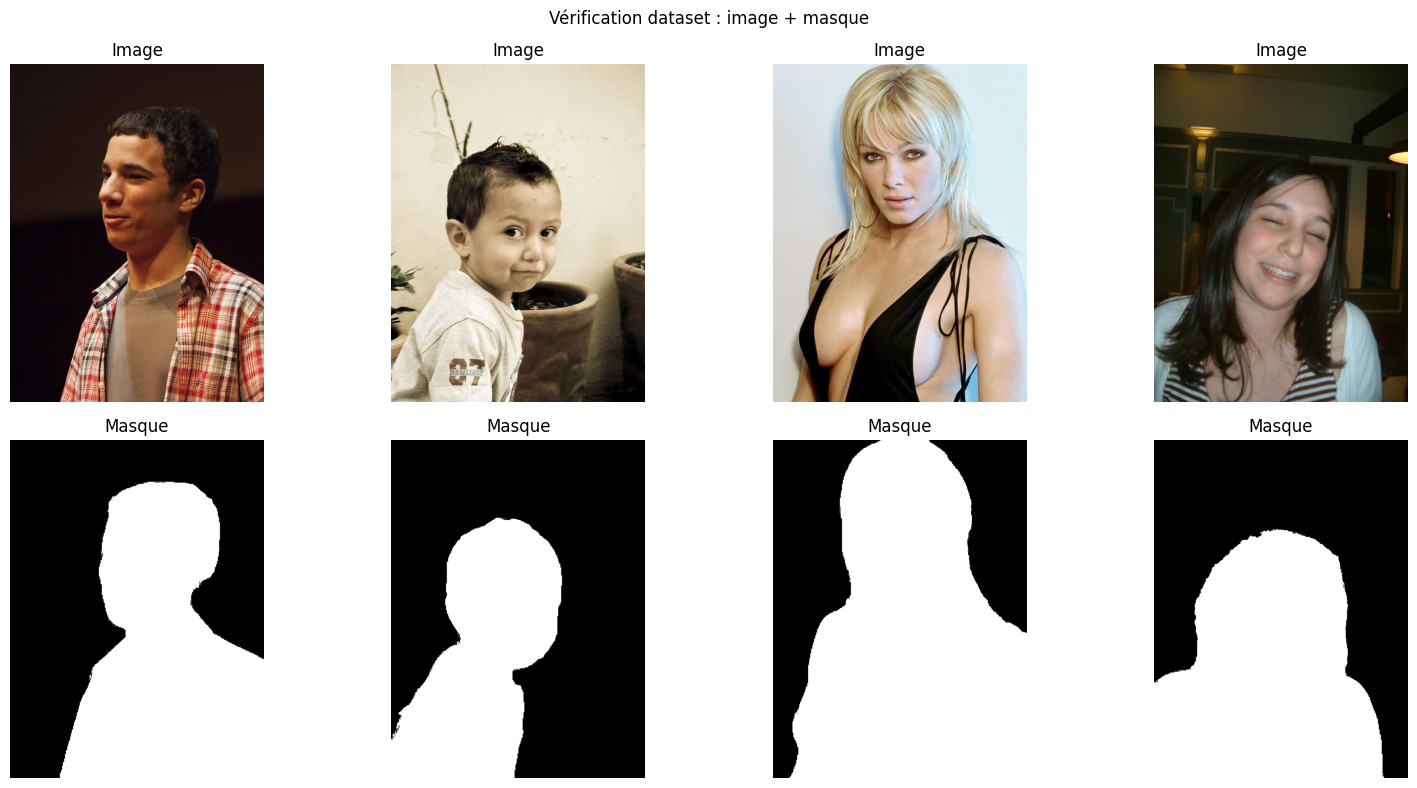

In [ ]:
# Décodage bitmap Supervisely (base64 → zlib → PNG palette)
def decode_bitmap(data, origin, img_h, img_w):
    bmp  = Image.open(io.BytesIO(zlib.decompress(base64.b64decode(data)))).convert('L')
    arr  = np.array(bmp)
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    ox, oy = origin[0], origin[1]
    bh, bw = arr.shape
    y2, x2 = min(oy + bh, img_h), min(ox + bw, img_w)
    mask[oy:y2, ox:x2] = (arr[:y2-oy, :x2-ox] > 127).astype(np.uint8) * 255
    return mask

def load_mask(ann_path):
    ann  = json.loads(Path(ann_path).read_text())
    h, w = ann['size']['height'], ann['size']['width']
    mask = np.zeros((h, w), dtype=np.uint8)
    for obj in ann['objects']:
        if obj['geometryType'] == 'bitmap' and obj['classTitle'] == 'human':
            mask = np.maximum(mask, decode_bitmap(obj['bitmap']['data'], obj['bitmap']['origin'], h, w))
    return mask

# Visualisation : 4 paires image-masque
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ann_path in enumerate(random.sample(anns, 4)):
    img_path = CFG['img_dir'] / ann_path.name.replace('.json', '')
    img  = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    mask = load_mask(ann_path)
    axes[0, i].imshow(img);               axes[0, i].set_title('Image');  axes[0, i].axis('off')
    axes[1, i].imshow(mask, cmap='gray'); axes[1, i].set_title('Masque'); axes[1, i].axis('off')
plt.suptitle('Vérification dataset : image + masque')
plt.tight_layout(); plt.show()


In [ ]:
# Génération des splits train/val/test (groupé par clip car évite le data leakage)
clips = defaultdict(list)
for ann_path in anns:
    ann   = json.loads(ann_path.read_text())
    group = next((t['value'] for t in ann['tags'] if t['name'] == 'group'), 'default')
    clip  = next((t['value'] for t in ann['tags'] if t['name'] == 'clip'),  0) # clip signifie un groupe d'images
    clips[f'{group}_{clip}'].append(ann_path.stem.replace('.jpg', ''))

keys = list(clips.keys())
random.seed(42); random.shuffle(keys)
n = len(keys)
split_keys = {'train': keys[:int(n*.8)], 'val': keys[int(n*.8):int(n*.9)], 'test': keys[int(n*.9):]}

for name, ks in split_keys.items():
    names = [n for k in ks for n in clips[k]]
    (CFG['splits_dir'] / f'{name}.txt').write_text('\n'.join(names))
    print(f'{name:5s}: {len(names):>6} images')


train:  27302 images
val  :   3069 images
test :   4054 images


In [ ]:
# PyTorch Dataset
MEAN = np.array([0.485, 0.456, 0.406]) # valeurs moyennes RGB (ImageNet)
STD  = np.array([0.229, 0.224, 0.225]) # valeurs std RGB (ImageNet)

def get_transforms(is_train):
    ops = [A.HorizontalFlip(p=0.5), A.Rotate(limit=15, p=0.4),
           A.RandomBrightnessContrast(p=0.3)] if is_train else []
    return A.Compose(ops + [A.Resize(CFG['img_size'], CFG['img_size'])])

class SilhouetteDataset(Dataset):
    def __init__(self, split, is_train):
        self.names = (CFG['splits_dir'] / f'{split}.txt').read_text().splitlines()
        self.tfm   = get_transforms(is_train)
    def __len__(self): return len(self.names)
    def __getitem__(self, idx):
        name  = self.names[idx]
        img   = cv2.cvtColor(cv2.imread(str(CFG['img_dir'] / f'{name}.jpg')), cv2.COLOR_BGR2RGB)
        mask  = load_mask(CFG['ann_dir'] / f'{name}.jpg.json')
        aug   = self.tfm(image=img, mask=mask)
        img   = torch.tensor(((aug['image'] / 255. - MEAN) / STD).transpose(2,0,1), dtype=torch.float32)
        mask  = torch.tensor((aug['mask'] > 127).astype(np.float32)).unsqueeze(0)
        return img, mask

train_loader = DataLoader(SilhouetteDataset('train', True),  CFG['batch_size'], shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(SilhouetteDataset('val',   False), CFG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(SilhouetteDataset('test',  False), CFG['batch_size'], shuffle=False, num_workers=4, pin_memory=True)

imgs_b, masks_b = next(iter(train_loader))
print(f'Batch images : {imgs_b.shape} | Batch masques : {masks_b.shape} | Valeurs uniques masque : {masks_b.unique().tolist()}')


Batch images : torch.Size([16, 3, 512, 512]) | Batch masques : torch.Size([16, 1, 512, 512]) | Valeurs uniques masque : [0.0, 1.0]


In [ ]:
# Modèle U-Net + ResNet34 (ImageNet)
model = smp.Unet(encoder_name=CFG['encoder'], encoder_weights='imagenet',
                 in_channels=3, classes=1, activation=None).to(device)
print(f'Paramètres : {sum(p.numel() for p in model.parameters())/1e6:.1f}M')


Paramètres : 24.4M


In [ ]:
# Entraînement
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(preds, masks):
    return dice_loss(preds, masks) + bce_loss(preds, masks)
optimizer = AdamW(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
scaler    = torch.cuda.amp.GradScaler(enabled=CFG['amp'])

with open(CFG['log_path'], 'w', newline='') as f:
    csv.writer(f).writerow(['epoch','train_loss','val_loss','val_iou','val_f1'])

history    = {'train_loss':[],'val_loss':[],'val_iou':[],'val_f1':[]}
best_iou   = 0.0
no_improve = 0

for epoch in range(1, CFG['epochs'] + 1):
    # Train
    model.train(); train_loss = 0
    for imgs, masks in tqdm(train_loader, desc=f'Ep {epoch} train'):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.autocast('cuda', enabled=CFG['amp']):
            loss = loss_fn(model(imgs), masks)
        scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Val
    model.eval(); val_loss = 0; tp_s=fp_s=fn_s=tn_s=0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f'Ep {epoch} val  '):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            val_loss += loss_fn(preds, masks).item()
            tp,fp,fn,tn = smp.metrics.get_stats((torch.sigmoid(preds)>.5).long(), masks.long(), mode='binary')
            tp_s+=tp.sum(); fp_s+=fp.sum(); fn_s+=fn.sum(); tn_s+=tn.sum()
    val_loss /= len(val_loader)
    val_iou = smp.metrics.iou_score(tp_s,fp_s,fn_s,tn_s,reduction='micro').item()
    val_f1  = smp.metrics.f1_score(tp_s,fp_s,fn_s,tn_s,reduction='micro').item()
    scheduler.step()

    for k,v in zip(history,[train_loss,val_loss,val_iou,val_f1]): history[k].append(v)
    with open(CFG['log_path'],'a',newline='') as f:
        csv.writer(f).writerow([epoch,round(train_loss,4),round(val_loss,4),round(val_iou,4),round(val_f1,4)])

    print(f'Ep {epoch:02d} | train={train_loss:.4f} | val={val_loss:.4f} | IoU={val_iou:.4f} | F1={val_f1:.4f}')

    if val_iou > best_iou:
        best_iou = val_iou; no_improve = 0
        torch.save({'epoch':epoch,'val_iou':val_iou,'state_dict':model.state_dict()}, CFG['ckpt_path'])
        print(f'  ✓ Best checkpoint (IoU={best_iou:.4f})')
    else:
        no_improve += 1
        if no_improve >= CFG['patience']:
            print(f'Early stopping à epoch {epoch}'); break

print(f'\nDone. Best val IoU : {best_iou:.4f}')


/tmp/ipykernel_534155/2199821715.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler(enabled=CFG['amp'])


Ep 1 train:   0%|          | 0/1707 [00:00<?, ?it/s]

Ep 1 val  :   0%|          | 0/192 [00:00<?, ?it/s]

Ep 01 | train=0.1405 | val=0.0457 | IoU=0.9814 | F1=0.9906
  ✓ Best checkpoint (IoU=0.9814)


Ep 2 train:   0%|          | 0/1707 [00:00<?, ?it/s]

...

Ep 15 train:   0%|          | 0/1707 [00:00<?, ?it/s]

Ep 15 val  :   0%|          | 0/192 [00:00<?, ?it/s]

Ep 15 | train=0.0272 | val=0.0302 | IoU=0.9857 | F1=0.9928


Ep 16 train:   0%|          | 0/1707 [00:00<?, ?it/s]

KeyboardInterrupt: 

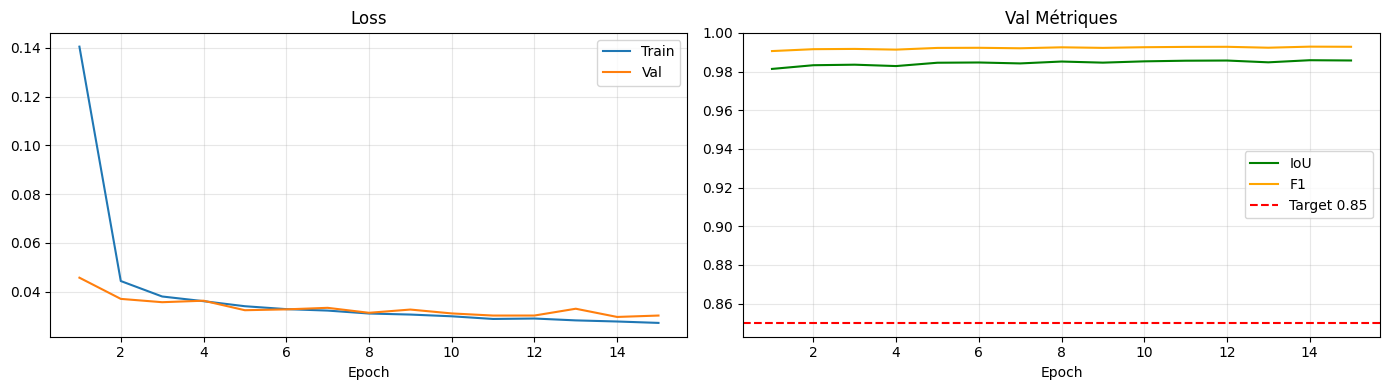

In [ ]:
# Courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, len(history['train_loss'])+1)
ax1.plot(ep, history['train_loss'], label='Train'); ax1.plot(ep, history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=.3)
ax2.plot(ep, history['val_iou'], label='IoU', color='green')
ax2.plot(ep, history['val_f1'],  label='F1',  color='orange')
ax2.axhline(0.85, color='red', linestyle='--', label='Target 0.85')
ax2.set_title('Val Métriques'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=.3)
plt.tight_layout(); plt.show()


In [ ]:
# Évaluation test set
ckpt = torch.load(CFG['ckpt_path'], map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval(); tp_s=fp_s=fn_s=tn_s=0
with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Test'):
        imgs, masks = imgs.to(device), masks.to(device)
        preds = (torch.sigmoid(model(imgs)) > .5).long()
        tp,fp,fn,tn = smp.metrics.get_stats(preds, masks.long(), mode='binary')
        tp_s+=tp.sum(); fp_s+=fp.sum(); fn_s+=fn.sum(); tn_s+=tn.sum()
print('='*40)
print(f'  IoU    : {smp.metrics.iou_score(tp_s,fp_s,fn_s,tn_s,reduction="micro").item():.4f}  (target > 0.85)')
print(f'  F1     : {smp.metrics.f1_score(tp_s,fp_s,fn_s,tn_s,reduction="micro").item():.4f}')
print(f'  Recall : {smp.metrics.recall(tp_s,fp_s,fn_s,tn_s,reduction="micro").item():.4f}')
print('='*40)


Test:   0%|          | 0/254 [00:00<?, ?it/s]

  IoU    : 0.9856  (target > 0.85)
  F1     : 0.9928
  Recall : 0.9910


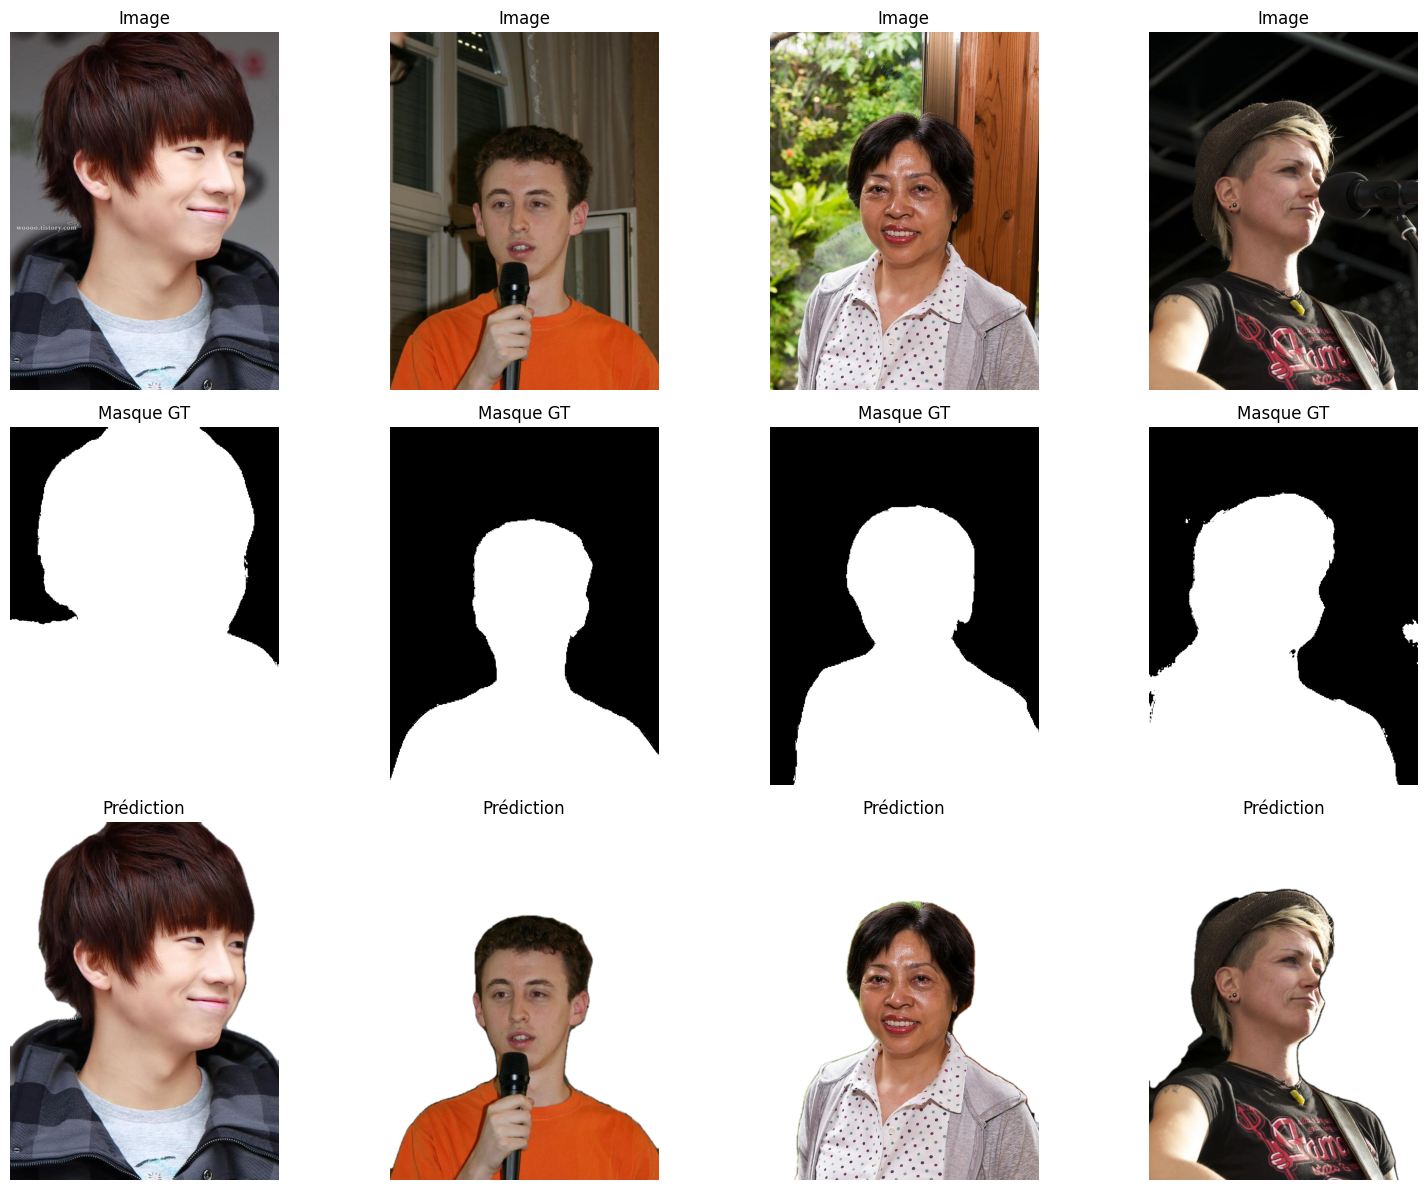

In [ ]:
# Inférence + visualisation sur 4 images du test set
def infer(img_path):
    bgr = cv2.imread(str(img_path))
    h, w = bgr.shape[:2]
    rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    t    = torch.tensor(((cv2.resize(rgb,(CFG['img_size'],CFG['img_size']))/255.-MEAN)/STD).transpose(2,0,1),
                        dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = torch.sigmoid(model(t))[0,0].cpu().numpy()
    mask = cv2.resize(pred, (w, h))

    # POST-PROCESSING
    mask = (mask > 0.4).astype(np.uint8) * 255

    # Garde uniquement le plus grand contour
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        mask = np.zeros_like(mask)
        cv2.drawContours(mask, [max(contours, key=cv2.contourArea)], -1, 255, cv2.FILLED)

    # Fermeture morphologique
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Bords doux
    mask = cv2.GaussianBlur(mask, (5, 5), 0)
    # ── FIN POST-PROCESSING ──

    return rgb, mask

test_names = (CFG['splits_dir']/'test.txt').read_text().splitlines()
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, name in enumerate(random.sample(test_names, 4)):
    img, pred_mask = infer(CFG['img_dir'] / f'{name}.jpg')
    gt = load_mask(CFG['ann_dir'] / f'{name}.jpg.json')
    axes[0,i].imshow(img);               axes[0,i].set_title('Image');     axes[0,i].axis('off')
    axes[1,i].imshow(gt, cmap='gray');   axes[1,i].set_title('Masque GT'); axes[1,i].axis('off')
    axes[2,i].imshow(np.dstack([img,pred_mask])); axes[2,i].set_title('Prédiction'); axes[2,i].axis('off')
plt.tight_layout(); plt.show()


✓ Exporté : poutou.png


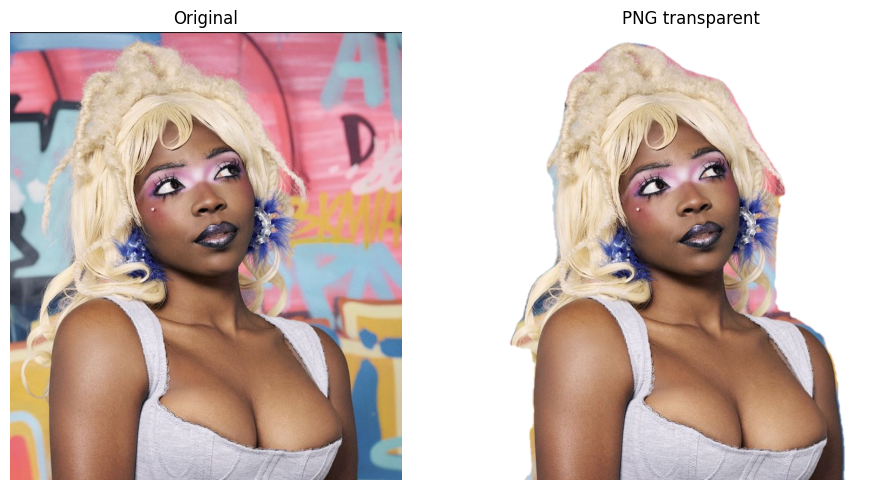

In [84]:
# ── Export PNG transparent — change INPUT_IMAGE
# for k in range(68): 
    # to_add = str(k)
    # if len(to_add) < 2:
        # to_add = '0' + to_add
    #INPUT_IMAGE  = 'video_output/frame_00' + to_add + '.png'   
    #OUTPUT_IMAGE = 'video_output2/frame'+to_add+'.png'
INPUT_IMAGE  = 'paupau/teodora.jpg'
OUTPUT_IMAGE = 'poutou.png'
img_rgb, mask = infer(INPUT_IMAGE)
Image.fromarray(np.dstack([img_rgb, mask]), 'RGBA').save(OUTPUT_IMAGE)
print(f'✓ Exporté : {OUTPUT_IMAGE}')

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(img_rgb);                      ax[0].set_title('Original');        ax[0].axis('off')
ax[1].imshow(np.dstack([img_rgb,mask]));    ax[1].set_title('PNG transparent'); ax[1].axis('off')
plt.tight_layout(); plt.show()
